Geo Data Science with Python,
Prof. Susanna Werth, VT Geosciences

---
### Basic Tutorials

# Pandas

This lesson discusses the Python Module **Pandas**. 

Learning goals of this lesson notebook and the following problem notebook are:

* Read data from a .csv text file into Python using Pandas
* Do simple data analysis using Pandas data structures and related functions
* Write data from Pandas to a .csv text file

### Sources
These lessons are an adaption of the Pandas lesson from [Geo-Python 2018](https://geo-python.github.io/site/2018/lessons/L5/pandas.html), which is licensed under a Creative Commons Attribution-ShareAlike 4.0 International licence.

---


<img src="./image_Pandas.png" width="600" />

#  What is Pandas?

[Pandas](https://pandas.pydata.org/) is a modern and feature rich data analysis framework for Python that is designed to make data analysis and manipulation straightforward and powerful using easy-to-use data structures and operations. It is a mature data analytics framework that is widely used among different fields of science, thus there exists a lot of good examples and documentation that can help you get going with your data analysis tasks.
Pandas offspring **GeoPandas** is widely used in GIS data anlysis problems. 

## Easy-to-use data structures

In Pandas the data is typically stored into a **DataFrame** that looks like a typical table with rows and columns (marked with indices and column names). The columns can contain data of different data types. Thus, the way data is stored looks similar to Excel sheets.

## Combines functionalities from many Python modules

Pandas takes advantage of the [numpy](http://www.numpy.org/)-module which runs under the hood and is mostly written in C, which makes it fast and powerful library that can handle large datasets. However, Pandas offers a more intuitive syntax. However, Pandas is much more than easier-to-use numpy as it also combines many functionalities from other Python libraries such as [matplotlib](https://matplotlib.org/) (plotting) and [scipy](https://www.scipy.org/) (mathematics, science, engineering). Thus, you can use many features included in those packages without importing them.

## Supports data reading & writing for a variety of formats

One of the most useful features of Pandas is its ability to read data from numerous different data formats directly. For example, Pandas supports reading and writing data from/to:

* CSV
* JSON
* HTML
* MS Excel
* HDF5
* Stata
* SAS
* Python Pickle format
* SQL (Postgresql, MySQL, Oracle, MariaDB, etc.)

See a full list from [Pandas' documentation pages](http://pandas.pydata.org/pandas-docs/version/0.20/io.html). Then let's look into the details of what Pandas offers.

# A. Exploring Data Using Pandas

We begin with learning how to read and explore data files using Pandas. We will continue to explore the Finnland weather data (some information on that below), to get familiar with Pandas data structures: **Series** and **DataFrame**. 

Pandas **DataFrame** (a 2-dimensional data structure) is used for storing and mainpulating table-like data (data with rows and columns) in Python. You can think of Pandas DataFrame as an attribute table (an excel-like spreadsheet, but much better!). Pandas Series (a 1-dimensional data structure) is used for storing and manipulating a sequence of values. Pandas DataFrames are very easy to access, because they combine the sequential features of lists with mapping features of dictionaries in one object type.

Pandas **Series** is similar to a list, but more clever. One row or one column in a Pandas DataFrame is actually a Pandas Series. 

For a comprehensive overview of pandas data structures, you can have a look at Wes MacKinney’s book [Python for Data Analysis (2nd Edition, 2017) on GitHub](https://github.com/wesm/pydata-book) and [Pandas online documentation](https://pandas.pydata.org/pandas-docs/stable/getting_started/dsintro.html) about data structures.

Reading data files using Pandas will make life a bit easier compared to the traditional Python way of reading data files, similar to the options in the NumPy module.


## The data

The data we will be working with are weather observations stored in the text file `Kumpula-June-2016-w-metadata.txt` (in the subdirectory `data`), which we have already been using in the course module 4. The data file is a 30-lines cutout of data downloaded from the climate data base of the [National Oceanographic and Atmospheric Administration](https://www.ncdc.noaa.gov/cdo-web/) (NOAA). It contains observed daily mean, minimum, and maximum temperatures from June 2016 recorded from the Kumpula weather observation station in Helsinki. Have a look into the file, before working with it.

## Reading a data file with Pandas

Now we’re ready to read in our temperature data file. But first, we need to import the Pandas module:

In [1]:
import pandas as pd

Pandas is ready to use now. Take note that we imported the Pandas module with the acronym `pd`. 

**Now we’ll read the file data into a variable called ``dataFrame``**. Using the function `pandas.read_csv()`.

In [3]:
# Read the file using pandas
dataFrame = pd.read_csv('Kumpula-June-2016-w-metadata.txt')

The Pandas `pd.read_csv()` is a general function for reading data files separated by commas, spaces, or other common separators. For a full list of parameters for this function, please refer to [pandas documentation page for pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html).

To use the function, we pass simply the filename as input parameter. You should now have a new variable defined as `dataFrame` in the memory, which stored the content of the file. You can check that by typing

In [4]:
dataFrame

,# Data file contents: Daily temperatures (mean,min,max) for Kumpula,Helsinki
0,# for June 1-30,2016,NaN,NaN
1,# Data source: https://www.ncdc.noaa.gov/cdo-w...,NaN,NaN,NaN
2,# Data processing: Extracted temperatures from...,converted to,NaN,NaN
3,# comma-separated format,NaN,NaN,NaN
4,#,NaN,NaN,NaN
5,# David Whipp - 02.10.2017,NaN,NaN,NaN
6,YEARMODA,TEMP,MAX,MIN
7,20160601,65.5,73.6,54.7
8,20160602,65.8,80.8,55.0
9,20160603,68.4,77.9,55.6


This looks OK, but there `NaN` values present. `NaN` stands for "not a number", and might indicate that there were some problems when reading the file. 

In addition, the first lines of the dataframe store metadata (from the header of the file), not data. We expected about 30 lines of data, but the index values count up to 36 when we print the content of the `dataFrame` variable to screen. It looks like we need to investigate this further.

The metadata at the top of the file provide some basic information about the file content and its source. This isn't data we want to process, so we need to skip over that part of the file when we load it.

Here are the first eigth rows of data in the text file (note that the 8th row is blank):

```
# Data file contents: Daily temperatures (mean, min, max) for Kumpula, Helsinki
#                     for June 1-30, 2016
# Data source: https://www.ncdc.noaa.gov/cdo-web/search?datasetid=GHCND
# Data processing: Extracted temperatures from raw data file, converted to
#                  comma-separated format
#
# David Whipp - 02.10.2017

```

Skipping over the header is easy to implement in Pandas, we just **add the `skiprows` parameter when we read the file, listing the number of rows to skip (8 in this case).**

Let's read the datafile again, this time defining the `skiprows` parameter.

In [5]:
dataFrame = pd.read_csv('Kumpula-June-2016-w-metadata.txt', skiprows=8)

Let's now print the rows and see what changed.

In [6]:
dataFrame

,YEARMODA,TEMP,MAX,MIN
0,20160601,65.5,73.6,54.7
1,20160602,65.8,80.8,55.0
2,20160603,68.4,77.9,55.6
3,20160604,57.5,70.9,47.3
4,20160605,51.4,58.3,43.2
5,20160606,52.2,59.7,42.8
6,20160607,56.9,65.1,45.9
7,20160608,54.2,60.4,47.5
8,20160609,49.4,54.1,45.7
9,20160610,49.5,55.9,43.0


That looks more like it.

But, why did the dataframe look so weird before we skipped the first rows? 

The file data was read into a Pandas **DataFrame**, which is  a two-dimensional structure used for storing table-like data. A pandas dataframe contains a collection of columns. And each column can be of different data type (string, float, int, boolean, etc.).

In our first attempt to read data from the text file, the first rows containing metadata did not belong to the actual data array, which caused the automatic data structure detection of the `read_csv()` function to fail. **Indeed, the `read_csv`-function expects column names in the first line of the file, by default.** For other options to skip the header, study the parameter `header` in the [read_csv documentation](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html).

**What would happen if we skipped 9 rows? (try it out!)**

In [7]:
# write your trial here, but make sure to re-run the correct command after this trial


Pandas DataFrames are so useful, because they come with labelled axes (rows and columns).  For our example above, the rows were labeled with an index value (`0` to `29`), and the columns were labelled `YEARMODA`, `TEMP`, `MAX`, and `MIN`. Now we can easily use these labels to divide up our data and make interacting with it easier as you'll see later in the lesson.

The mistake we made above (trying to read a datafile with some header text) is *very* common. Therefore, **it always helps to first get a sense of what the datafile looks like before you try to read it**. 

After reading in the data, make sure to check that everything went well (for example with the print-statement). Another challenge may be that large datafiles might not nicely print on screen using the `print()`-function. In this case, request only the top 5-10 lines of the file. 

**To check the contents of the dataframe, we can  use `pandas.DataFrame.head`-function.** This function returns the first n rows for the dataframe. By default, it returns the first five rows.

In [7]:
dataFrame.head()

,YEARMODA,TEMP,MAX,MIN
0,20160601,65.5,73.6,54.7
1,20160602,65.8,80.8,55.0
2,20160603,68.4,77.9,55.6
3,20160604,57.5,70.9,47.3
4,20160605,51.4,58.3,43.2


To get the tail of the dataset instead, use the function `tail()`. Now we can move on to exploring our data.

## Exploring our dataset: DataFrames and Series

A usual first step, when using new data, is to explore the dataset and getting to know its structure as well as what kind of values are stored in it.

**Let's look at the columns we have in our DataFrame.** We can receive this information requesting the built-in attribute `columns` of the DataFrame object:

In [8]:
#Print columns
print(dataFrame.columns)

Index(['YEARMODA', 'TEMP', 'MAX', 'MIN'], dtype='object')


Now you see the names of the columns in the datafile.

In addition, we can also **find information about the rows in the datafile using the ``index`` attribute**.

In [9]:
#Print index
print(dataFrame.index)

RangeIndex(start=0, stop=30, step=1)


This shows, how the data is indexed: Starting at 0, ending at 30, and an increment of 1 between each index value. This is basically the same way in which Python lists are indexed, which suggests there are other ways to identify the rows in data using Pandas.
   
We'll see a bit more about this later. For now, if you want to know **how many rows your data set has, you can use also ``len()`` function**:

In [10]:
# Print number of rows using len()-function
# print(len(dataFrame.index))
print(len(dataFrame))

30


**We can also request the size of the dataset with the ``shape`` attribute**:


In [11]:
# Print dataframe shape
print(dataFrame.shape)

(30, 4)


Our dataset has 30 rows, 4 columns, exaclty as we know from above.

Now we want to investigate the **type data** we have in our DataFrame. Let's first request the object type of `dataFrame`:

In [12]:
# check data type of the dataFrame variable
type(dataFrame)

pandas.core.frame.DataFrame

No surprises here, our Pandas variable `DataFrame` is a Pandas **DataFrame** 😉.

The IPython magic command `%who` is also useful to get such information about the DataFrame variables:

In [13]:
# Display variable name, type and info
%whos

Variable    Type         Data/Info
----------------------------------
dataFrame   DataFrame    Shape: (30, 4)
pd          module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>


Next, let's look into the types of data in the columns of the `dataFrame` variable. The attribute **dtypes** helps to find that out:

In [14]:
# Print data types
print(dataFrame.dtypes)

YEARMODA      int64
TEMP        float64
MAX         float64
MIN         float64
dtype: object


The ``dtypes`` attribute holds the data types for each column.
For our example, we see that ``YEARMODA`` is an integer value (with 64-bit precision; int64), while all other values are decimal values with 64-bit precision (float64).

In addition, we can also **select a single column of `dataFrame` by referencing it with the name of that column**. And printing out the values of a column, shows not only the values, but also their data type, at the bottom of the column:

In [15]:
#Print out a single column
dataFrame['TEMP'].head()

0    65.5
1    65.8
2    68.4
3    57.5
4    51.4
Name: TEMP, dtype: float64

And finally, the **entire column itself has its own object type**:

In [16]:
# Check datatype of that column
type(dataFrame['TEMP'])

pandas.core.series.Series

This is a Pandas **Series**.

So while the items in the DataFrame column are of float64 data type, an entire column of a DataFrame is called a *Series* in Pandas. Let's briefly discuss how you can create a Pandas Series from a Python list (and further convert it into a Pandas DataFrame). 

If you have long lists of numbers, you can convert them into a Pandas Series, which will allow you to interact with these values more efficiently (in terms of computation times). 

For example, a list **``myList`` is converted to a Pandas Series using the ``ps.Series()`` function**. 

In [17]:
# Create Pandas Series from a list
myList = [1, 2, 3, 4, 5, 6, 7.0]
mySeries = pd.Series(myList)
print(mySeries)

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
6    7.0
dtype: float64


Also, note that Pandas is smart about the conversion: it detects a single floating point value (``7.0``) and then assigns the data type float64 to all values in the Series.

We could also **convert the Pandas Series into a Pandas DataFrame** by initiating a new [pandas.DataFrame()](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.html):

In [18]:
# Check data type of the input
print(type(mySeries))

# Create a pandas dataframe
myDataFrame = pd.DataFrame(mySeries)

#Check the data type
print(type(myDataFrame))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [19]:
print(myDataFrame)

     0
0  1.0
1  2.0
2  3.0
3  4.0
4  5.0
5  6.0
6  7.0


So, now we have a pandas dataframe with one column of data, and an associated index. By default, the column name (label) has been set to '0'. We can **give the column a new name** applying the foolowing syntax:

In [20]:
# Rename the first column
myDataFrame.columns = ["number"]
print(myDataFrame)

   number
0     1.0
1     2.0
2     3.0
3     4.0
4     5.0
5     6.0
6     7.0


Now, let's continue with our original DataFrame `dataFrame`.

## Common Methods for DataFrames and Series

Just like DataFrames, Pandas Series have a set of attributes and methods, which support fast access to and processing of the data.

**Useful methods include `mean()`, `median()`, `min()`, `max()`, and `std()`** (the standard deviation).

Note, that we don't need to store `dataFrame['TEMP']` into a separate series variable in order to apply the `mean()` method.

Another useful function is the **``describe()`` function, which provides an overview of the basic statistics for all attributes in your DataFrame**:

In [21]:
# Check mean value of a column
dataFrame['TEMP'].mean()

np.float64(59.730000000000004)

In [22]:
# Get descriptive statistics
dataFrame.describe()

,YEARMODA,TEMP,MAX,MIN
count,3.000000e+01,30.000000,30.000000,30.000000
mean,2.016062e+07,59.730000,67.940000,51.750000
std,8.803408e+00,5.475472,6.651761,5.634484
min,2.016060e+07,49.400000,54.100000,41.700000
25%,2.016061e+07,56.450000,63.150000,47.300000
50%,2.016062e+07,60.050000,69.000000,54.050000
75%,2.016062e+07,64.900000,72.375000,55.750000
max,2.016063e+07,69.600000,80.800000,60.300000


Lastly, **Series allow for type conversions**. For example, if you're planning to print a large number of values to the screen, it might be helpful to transfer those values to character strings. You can achieve such a **type conversions with the `astype()` method** (congruent to NumPy's `astype()`).

In [23]:
#Convert temperature values to string
print(dataFrame['TEMP'].astype(str))

0     65.5
1     65.8
2     68.4
3     57.5
4     51.4
5     52.2
6     56.9
7     54.2
8     49.4
9     49.5
10    54.0
11    55.4
12    58.3
13    59.7
14    63.4
15    57.8
16    60.4
17    57.3
18    56.3
19    59.3
20    62.6
21    61.7
22    60.9
23    61.1
24    65.7
25    69.6
26    60.7
27    65.4
28    65.8
29    65.7
Name: TEMP, dtype: object


After convertion, the data type `object` indicates that the temperature values were converted to character strings. A more obvious result is given, when converting them to integer values.

In [24]:
# Check the output
dataFrame['TEMP'].astype(int)

0     65
1     65
2     68
3     57
4     51
5     52
6     56
7     54
8     49
9     49
10    54
11    55
12    58
13    59
14    63
15    57
16    60
17    57
18    56
19    59
20    62
21    61
22    60
23    61
24    65
25    69
26    60
27    65
28    65
29    65
Name: TEMP, dtype: int64

The temperature values were cut off to integer numbers.

<div class="alert alert-warning">

**Note:**

Be careful with type conversions from floating point values to integers. The conversion simply truncates the numbers at the decimal point. Hence, so all values are rounded down. For example, 99.99 will be rounded to 99.

</div>


It might be good to round the values before converting them to integers. You can **chain the `round()` and `type()` functions together**. The **command chain `.round(0).astype(int)`**, first rounds the values with zero decimals and then it converts those values into integers.

In [25]:
# Integer, truncated:
print("Truncated values:")
print(dataFrame['TEMP'].astype(int).head())

# Add empty line:
print("\n")

print("Rounded values:")
#Integer, rounded:
print(dataFrame['TEMP'].round(0).astype(int).head())

Truncated values:
0    65
1    65
2    68
3    57
4    51
Name: TEMP, dtype: int64


Rounded values:
0    66
1    66
2    68
3    58
4    51
Name: TEMP, dtype: int64


Here we stop our exploration, and we would like to continue with data processing.

---
# B. Processing Data with Pandas

After discussin the basics of Pandas data structures **DataFrames** and **Series**, we will continue to explore available operations for data analysis.

Let's first read the same data as before into a Pandas DataFrame to have a clean start. Then we will focus on a few new aspects of importing data.

In [27]:
import pandas as pd

fp = r'Kumpula-June-2016-w-metadata.txt'
dataFrame = pd.read_csv(fp, sep=',', skiprows=8)

Please note two things in the code above:

- **'r' prefix** in front of the filepath string. 
- **`sep=','`** parameter in the `read_csv()` function defines a delimiter. 

In our case, both of these details are not needed (the code works correctly without them), but they might come in handy in the future. 

The letter 'r' makes sure that the filepath is interpreted correctly. Without the 'r', backslashes are treated as escape characters. With the r, backslashes are treated as literal. This becomes relevant, if you define full filepaths with the filename on a windows computer.

The **default delimiter in the `read_csv()` function is a comma (`,`)**. The example shows, how you could also define other characers and expressions as delimiter. In our case, however, the correct delimiter is a comma.

## Data Processing with DataFrames

One of the most common things performed with Pandas objects, is to **create new columns based on calculations between other variables (columns)**.

We can create a new column into our DataFrame, by specifying the name of the column and giving it some default value. In an example below, we create a new **column** `'DIFF'` and specify a decimal number 0.0 as default value:

In [28]:
# Define a new column "DIFF"
dataFrame['DIFF'] = 0.0

# Print the dataframe
dataFrame.head()

,YEARMODA,TEMP,MAX,MIN,DIFF
0,20160601,65.5,73.6,54.7,0.0
1,20160602,65.8,80.8,55.0,0.0
2,20160603,68.4,77.9,55.6,0.0
3,20160604,57.5,70.9,47.3,0.0
4,20160605,51.4,58.3,43.2,0.0


Now, let's check the datatype of the new column

In [29]:
# Check datatypes
dataFrame['DIFF'].dtypes

dtype('float64')

So, Pandas created a new column and automatically recognized that the data if of type float.

In addition, we can **perform calculations with the columns in the DataFrame**. Let's update the column ``DIFF`` by calculating the difference between the ``MAX`` and ``MIN`` columns. This will give insight into how much the temperatures have been varying during different days. 

Calculations can be done with the following syntax. First, we specify the column we want to update (i.e. ``DIFF``) and then we add the actual calculation by entering the names of the columns in our dataFrameFrame, accordingly:

In [30]:
#Calculate max min difference
dataFrame['DIFF'] = dataFrame['MAX'] - dataFrame['MIN']

# Print the dataframe
dataFrame.head()

,YEARMODA,TEMP,MAX,MIN,DIFF
0,20160601,65.5,73.6,54.7,18.9
1,20160602,65.8,80.8,55.0,25.8
2,20160603,68.4,77.9,55.6,22.3
3,20160604,57.5,70.9,47.3,23.6
4,20160605,51.4,58.3,43.2,15.1


From the output, we can see that he calculations were stored into the ``DIFF`` column. 

We can code this even more efficiently: we can **create new columns on-the-fly**, hence, together with the calculation. Let's test for a new column. This time we calculate the difference between the minimum temperature (``MIN``) and the mean temperature of each day (``TEMP``):

In [31]:
# Calculate difference between temp and min column values
dataFrame['DIFF_Min'] = dataFrame['TEMP'] - dataFrame['MIN']
dataFrame.head()

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min
0,20160601,65.5,73.6,54.7,18.9,10.8
1,20160602,65.8,80.8,55.0,25.8,10.8
2,20160603,68.4,77.9,55.6,22.3,12.8
3,20160604,57.5,70.9,47.3,23.6,10.2
4,20160605,51.4,58.3,43.2,15.1,8.2


This time, we created a new column and performed the calculation in one statement. Calculations like this can be performed using as many columns and operations (e.g. subtracttion, addition, multiplication, division, exponentiation, etc.) as needed.

For example, we can for example convert  Fahrenheit temperatures in ``TEMP`` column into Celsius using the formula we have applied many times before:

In [32]:
# Create a new column and convert temp fahrenheit to celsius:
dataFrame['TEMP_Celsius'] = (dataFrame['TEMP'] - 32) / (9/5)

#Check output
dataFrame.head()

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
0,20160601,65.5,73.6,54.7,18.9,10.8,18.611111
1,20160602,65.8,80.8,55.0,25.8,10.8,18.777778
2,20160603,68.4,77.9,55.6,22.3,12.8,20.222222
3,20160604,57.5,70.9,47.3,23.6,10.2,14.166667
4,20160605,51.4,58.3,43.2,15.1,8.2,10.777778


## Selecting data using indices

In Pandas, you can also select only specific rows from the DataFrame and apply operations to only those selected rows. However, there are different ways of coding this.

For example, you can **select specific rows from your DataFrame**, extracting part of the DataFrame. Since our dataset `dataFrame` is labeled with row numbers, this works with the row numbers and looks similar to list slicing. Let's select the first five rows and assign them to a new variable called ``rows5``:

In [33]:
# Select first five rows of dataframe
rows5 = dataFrame[0:5]
rows5

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
0,20160601,65.5,73.6,54.7,18.9,10.8,18.611111
1,20160602,65.8,80.8,55.0,25.8,10.8,18.777778
2,20160603,68.4,77.9,55.6,22.3,12.8,20.222222
3,20160604,57.5,70.9,47.3,23.6,10.2,14.166667
4,20160605,51.4,58.3,43.2,15.1,8.2,10.777778


The slicing is done similar to Python lists. One has to sepecify an index range that should be selected inside the square brackets: ``selection = dataFrame[start_index:stop_index]``.

You can also **select a single row at a specific position applying the ``.loc[]`` indexing method**. Below, we select all the data values from row 8:

In [34]:
# Select one row using index
row8 = dataFrame.loc[8]

print(row8)

YEARMODA        2.016061e+07
TEMP            4.940000e+01
MAX             5.410000e+01
MIN             4.570000e+01
DIFF            8.400000e+00
DIFF_Min        3.700000e+00
TEMP_Celsius    9.666667e+00
Name: 8, dtype: float64


The ``.loc[]`` indexing returns values as a ``pd.Series``. And the indices of the Series become the original column names. From the Series, you can access the value of an individual column by referring to its index or name. Use the following formats:

In [36]:
#Print content from the selected row
print(row8[1])

49.4


/var/folders/9g/ntrtgq0j4m12b903h7ptgrth0000gp/T/ipykernel_96592/3943775191.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(row8[1])


In [37]:
#Print content from the selected row
print(row8['TEMP'])

49.4


It is also possible to **select multiple rows simultaniously**. Below, only temperature values (``TEMP``) between indices of 5-10 are selected:

In [38]:
# Select temp column values between indices 5 and 10
temps_5to10 = dataFrame.loc[5:10, 'TEMP']

print(temps_5to10)

5     52.2
6     56.9
7     54.2
8     49.4
9     49.5
10    54.0
Name: TEMP, dtype: float64


And, it is possible to **select multiple columns and multiple rows**, the former based on a list of column names and the latter based on indices. Here, we select ``TEMP`` and the ``TEMP_Celsius`` columns by passing them as a list (``.loc[start_index:stop_index, list_of_columns]``):

In [39]:
# Select temp and temp_celsius column values between indices 5 and 10
temps_5to10 = dataFrame.loc[5:10, ['TEMP', 'TEMP_Celsius']]

print(temps_5to10)

    TEMP  TEMP_Celsius
5   52.2     11.222222
6   56.9     13.833333
7   54.2     12.333333
8   49.4      9.666667
9   49.5      9.722222
10  54.0     12.222222


And, of course, you can also **get all rows from those two selected columns**. This, can be achieved by referencing the `dataFrame` with the same list of column names inside square brackets:

In [40]:
# Select all rows from temp and temp_celsius columns
temps_only = dataFrame[['TEMP', 'TEMP_Celsius']]
temps_only.head()

,TEMP,TEMP_Celsius
0,65.5,18.611111
1,65.8,18.777778
2,68.4,20.222222
3,57.5,14.166667
4,51.4,10.777778


## Filtering and updating data

Another very useful feature in Pandas is the ability to **filter and select rows based on a conditional statement**.
The following example shows how to select those rows where the Celsius temperature is above 15 degrees and save them into the variable ``w_temps`` (warm temperatures).


In [41]:
# Select rows with temp celsius higher than 15 degrees
w_temps = dataFrame[dataFrame['TEMP_Celsius'] > 15]
w_temps.head()

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
0,20160601,65.5,73.6,54.7,18.9,10.8,18.611111
1,20160602,65.8,80.8,55.0,25.8,10.8,18.777778
2,20160603,68.4,77.9,55.6,22.3,12.8,20.222222
13,20160614,59.7,67.8,47.8,20.0,11.9,15.388889
14,20160615,63.4,70.3,49.3,21.0,14.1,17.444444


Furthermore, it is possible to combine multiple criteria at the same time. Below, we select temperatures above 15 degrees (i.e. `TEMP_Celsius` > 15) during the second half of June 2016 (i.e. ``YEARMODA >= 20160615``). For that, **the ``&`` operator (AND) or ``|`` operator (OR) combine multiple criteria**. Note, that it may be useful (i.e. easier to read), if you put the different clauses inside parentheses ``()``, to visually separate them from each other.

In [42]:
# Select rows with temp celsius higher than 15 degrees from late June 2016
w_temps2 = dataFrame[(dataFrame['TEMP_Celsius'] > 15) & (dataFrame['YEARMODA'] >= 20160615)]
w_temps2

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
14,20160615,63.4,70.3,49.3,21.0,14.1,17.444444
16,20160617,60.4,70.7,55.9,14.8,4.5,15.777778
19,20160620,59.3,69.1,52.2,16.9,7.1,15.166667
20,20160621,62.6,71.4,50.4,21.0,12.2,17.000000
21,20160622,61.7,70.2,55.4,14.8,6.3,16.500000
22,20160623,60.9,67.1,54.9,12.2,6.0,16.055556
23,20160624,61.1,68.9,56.7,12.2,4.4,16.166667
24,20160625,65.7,75.4,57.9,17.5,7.8,18.722222
25,20160626,69.6,77.7,60.3,17.4,9.3,20.888889
26,20160627,60.7,70.0,57.6,12.4,3.1,15.944444


Now we have a subset of our DataFrame that contains only rows with ``TEMP_Celsius`` above 15 and in which the dates in ``YEARMODA`` column start from 15th of June.

If you inspect the results above, you may have noticed that the index values (numbers to the left) are still showing the rows positions from the original DataFrame. It is possible to **reset the index of the DataFrame using the ``reset_index()`` function**. 

By default, the ``reset_index()`` makes a new column called ``index`` to keep track of the previous indicees, which might be useful in some cases. However, here we want to omit the old row numbers, which we can command by passing the **parameter ``drop=True``**.

In [43]:
# Reset index
w_temps2 = w_temps2.reset_index(drop=True)
w_temps2

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
0,20160615,63.4,70.3,49.3,21.0,14.1,17.444444
1,20160617,60.4,70.7,55.9,14.8,4.5,15.777778
2,20160620,59.3,69.1,52.2,16.9,7.1,15.166667
3,20160621,62.6,71.4,50.4,21.0,12.2,17.000000
4,20160622,61.7,70.2,55.4,14.8,6.3,16.500000
5,20160623,60.9,67.1,54.9,12.2,6.0,16.055556
6,20160624,61.1,68.9,56.7,12.2,4.4,16.166667
7,20160625,65.7,75.4,57.9,17.5,7.8,18.722222
8,20160626,69.6,77.7,60.3,17.4,9.3,20.888889
9,20160627,60.7,70.0,57.6,12.4,3.1,15.944444


In the reset DataFrame above, the index values count from 0 to 12.

## Dealing with missing data

In this section, we want to discuss how to deal with missing data. To be able to illustrate that, we have to manipulate our DataFrame `w_temps` and create some missing data, first. Let's change the top five values of ``TEMP_Celsius`` to ``NaN`` (not-a-number), which we can achieve by ``loc[]`` indexing:

In [44]:
# Set temp_celsius as none in the first five rows
w_temps2.loc[:4, 'TEMP_Celsius'] = None
print(w_temps2)

    YEARMODA  TEMP   MAX   MIN  DIFF  DIFF_Min  TEMP_Celsius
0   20160615  63.4  70.3  49.3  21.0      14.1           NaN
1   20160617  60.4  70.7  55.9  14.8       4.5           NaN
2   20160620  59.3  69.1  52.2  16.9       7.1           NaN
3   20160621  62.6  71.4  50.4  21.0      12.2           NaN
4   20160622  61.7  70.2  55.4  14.8       6.3           NaN
5   20160623  60.9  67.1  54.9  12.2       6.0     16.055556
6   20160624  61.1  68.9  56.7  12.2       4.4     16.166667
7   20160625  65.7  75.4  57.9  17.5       7.8     18.722222
8   20160626  69.6  77.7  60.3  17.4       9.3     20.888889
9   20160627  60.7  70.0  57.6  12.4       3.1     15.944444
10  20160628  65.4  73.0  55.8  17.2       9.6     18.555556
11  20160629  65.8  73.2  59.7  13.5       6.1     18.777778
12  20160630  65.7  72.7  59.2  13.5       6.5     18.722222


Now, the manipulated DataFrame contains exactly five missing values at the top of the column `TEMP_Celsius`.

<div class="alert alert-success">

**Note:**

You don't need to specify the starting index if you select data from the beginning of the DataFrame (at index 0). In this case, you can leave it empty, which works congruent to list indexing.

</div>

Missing data are very common in data sets, and typically you want make sure to to deal with them somehow. Common procedures to deal with `NaN`-values is to either **remove** them from
the DataFrame or to **fill** them with some value. In Pandas both of these options are available and easy to perform.

First, let's **clean the data by removing entries with `NaN`-values using the ``dropna()`` function**. The function accepts a ``subset`` parameter, which is a list of column names. These numbers provide the function with information, which columns should be searched for `NaN` values. Let's look at an example for the DataFrame `w_temps2.

In [45]:
# Drop no data values based on temp_celsius column
w_temps_clean = w_temps2.dropna(subset=['TEMP_Celsius'])

print(w_temps_clean)

    YEARMODA  TEMP   MAX   MIN  DIFF  DIFF_Min  TEMP_Celsius
5   20160623  60.9  67.1  54.9  12.2       6.0     16.055556
6   20160624  61.1  68.9  56.7  12.2       4.4     16.166667
7   20160625  65.7  75.4  57.9  17.5       7.8     18.722222
8   20160626  69.6  77.7  60.3  17.4       9.3     20.888889
9   20160627  60.7  70.0  57.6  12.4       3.1     15.944444
10  20160628  65.4  73.0  55.8  17.2       9.6     18.555556
11  20160629  65.8  73.2  59.7  13.5       6.1     18.777778
12  20160630  65.7  72.7  59.2  13.5       6.5     18.722222


As result, we get a DataFrame without the table rows that contained `NaN` values.

Now, let's look at the alternative option for cleaning the data. You can **fill the `NaN` values using the ``fillna()``-function**. In the example below, we will fill them with the value 0:

In [46]:
# Fill na values with 0
w_temps_na_filled = w_temps2.fillna(0)

print(w_temps_na_filled)

    YEARMODA  TEMP   MAX   MIN  DIFF  DIFF_Min  TEMP_Celsius
0   20160615  63.4  70.3  49.3  21.0      14.1      0.000000
1   20160617  60.4  70.7  55.9  14.8       4.5      0.000000
2   20160620  59.3  69.1  52.2  16.9       7.1      0.000000
3   20160621  62.6  71.4  50.4  21.0      12.2      0.000000
4   20160622  61.7  70.2  55.4  14.8       6.3      0.000000
5   20160623  60.9  67.1  54.9  12.2       6.0     16.055556
6   20160624  61.1  68.9  56.7  12.2       4.4     16.166667
7   20160625  65.7  75.4  57.9  17.5       7.8     18.722222
8   20160626  69.6  77.7  60.3  17.4       9.3     20.888889
9   20160627  60.7  70.0  57.6  12.4       3.1     15.944444
10  20160628  65.4  73.0  55.8  17.2       9.6     18.555556
11  20160629  65.8  73.2  59.7  13.5       6.1     18.777778
12  20160630  65.7  72.7  59.2  13.5       6.5     18.722222


As result, we get a DataFrame where `NaN`-values are replaced by the value 0.00000.

<div class="alert alert-warning">

**Warning:** In many cases filling the data with a specific value can hamper with your data analysis, because you basically enter artificial data values. This can affect the results of your (e.g. statistical) analysis. In the example, the mean Celsius temperature in the DataFrame will have changed significantly, because the 0 values are decreasing the average temperature of the month. Therefore, removing `NaN`-values is usually preferred over filling them. But if filling is used, it should be done and evaluated carefully.

</div>

## Sorting data

At some point, it might be neccessary to **sort your data in either descending or ascending order** based on values in a column. In Pandas this is done using the ``sort_values(by='YourColumnName')``-function. Let's sort the values of our entire `dataFrame` table based on the ``TEMP`` column and in ascending order:

In [47]:
# Sort dataframe, ascending
sorted_temp_a = dataFrame.sort_values(by='TEMP')
sorted_temp_a.head()

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
8,20160609,49.4,54.1,45.7,8.4,3.7,9.666667
9,20160610,49.5,55.9,43.0,12.9,6.5,9.722222
4,20160605,51.4,58.3,43.2,15.1,8.2,10.777778
5,20160606,52.2,59.7,42.8,16.9,9.4,11.222222
10,20160611,54.0,62.1,41.7,20.4,12.3,12.222222


Of course, it is also possible to sort them in descending order, which is achieved using the ``ascending=False`` parameter:

In [48]:
# Sort dataframe, descending
sorted_temp_d = dataFrame.sort_values(by='TEMP', ascending=False)
sorted_temp_d.head()

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius
25,20160626,69.6,77.7,60.3,17.4,9.3,20.888889
2,20160603,68.4,77.9,55.6,22.3,12.8,20.222222
1,20160602,65.8,80.8,55.0,25.8,10.8,18.777778
28,20160629,65.8,73.2,59.7,13.5,6.1,18.777778
29,20160630,65.7,72.7,59.2,13.5,6.5,18.722222


## Rounding and finding unique values

Numeric values can be **round using the ``round()``-function**. Below, we round the Celsius temperatures to 0-decimals:

In [49]:
# Create new column, and round celsius values
dataFrame['Celsius_rounded'] = dataFrame['TEMP_Celsius'].round(0)
dataFrame.head()

,YEARMODA,TEMP,MAX,MIN,DIFF,DIFF_Min,TEMP_Celsius,Celsius_rounded
0,20160601,65.5,73.6,54.7,18.9,10.8,18.611111,19.0
1,20160602,65.8,80.8,55.0,25.8,10.8,18.777778,19.0
2,20160603,68.4,77.9,55.6,22.3,12.8,20.222222,20.0
3,20160604,57.5,70.9,47.3,23.6,10.2,14.166667,14.0
4,20160605,51.4,58.3,43.2,15.1,8.2,10.777778,11.0


Sometimes it might be useful to **extract unique values from a column**.
This can be achived through the function ``unique_values()``:

In [50]:
# Get unique celsius values
unique = dataFrame['Celsius_rounded'].unique()
unique

array([19., 20., 14., 11., 12., 10., 13., 15., 17., 16., 21.])

As result, we receive a **numpy array** of unique values in the column `'Celsius_rounded'`.

**Note:** If your array of unique values is very long, you might not be able see all of them, as IPython collapses them. To circumvent that, print them as a list using the NumPy method `tolist()`. For that we have to import the NumPy module!

In [51]:
# unique values as list
import numpy
unique.tolist()

[19.0, 20.0, 14.0, 11.0, 12.0, 10.0, 13.0, 15.0, 17.0, 16.0, 21.0]

Now let's check: **How many days did we have unique mean temperature in June 2016?**

In [52]:
# Number of unique values
uniq_temp_days = len(unique)
print("There were", uniq_temp_days, "days with unique mean temperatures in June 2016.")

There were 11 days with unique mean temperatures in June 2016.


## Writing data

At last, we want to write the analyzed data into a file on our JupyterHub. For that, Pandas supports many different data formats by default (see the list at the top of this notebook).
By far the most typical output format is a **CSV-file** and the function **``to_csv()``** can be used to save your data in this format. 

Let's save the data in `dataFrame` into a file of the name `Kumpula_temp_results_June_2016.csv`:

In [54]:
# define output filename
output_fp = "Kumpula_temps_June_2016.csv"

# Save dataframe to csv
dataFrame.to_csv(output_fp, sep=',')

Using only one Pandas statement, we have saved the data from our DataFrame to a file. If you open the file in the in the text editor of the JupyterHub (which should locate in the folder `assignments_M6`), you should see the following:

<img src="./image_KumpulaResultsFile_editor.png" width="600" />

The first line contains the column names from our variable `dataFrame`. And the first entries on each further line in the datafile provide the index values for each data row. 

You can also see, that the numeric values in about the last four data columns contain quite many decimals. So, for our next file export, of the DataFrame ``w_temps``, we want to change the out put a bit. Let's reduce the precision of the numberic output to 1 decimal and save the temperature values without the index in the file `Kumpula_temps_above15_June_2016.csv`:

In [56]:
output_fp2 = "Kumpula_temps_above15_June_2016.csv"
w_temps.to_csv(output_fp2, sep=',', index=False, float_format="%.1f")

We have **ommitted the index with setting the index parameter to false: ``index=False``**. And the **``float_format`` parameter can control the number of decimals to be written**, for that the text ``%.1f`` informs the function to write all columns with 1 decimal to the file (changing the value 1 to 2 would write 2 decimals etc.)

<img src="./image_KumpulaResultsFile2_editor.png" width="400" />

This results in a "cleaner" output file, without the index column, and with only 1 decimal for floating point numbers.

---
# Plot data with Pandas
Plotting data with Pandas is very easy, because it comes with a .plot() methods. Below some examples:

In [60]:
# Convert dates to practical format and add to data frame
dates = pd.to_datetime(dataFrame['YEARMODA'],format='%Y%m%d')
dataFrame['DATES'] = dates

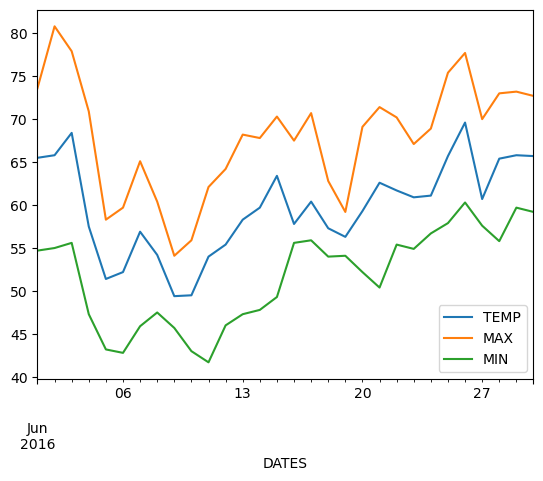

In [61]:
import matplotlib.pyplot as plt

# Plot several columns as lines
dataFrame.plot(x='DATES', y=["TEMP", "MAX", "MIN"]) # kind default value is 'line'
plt.show()

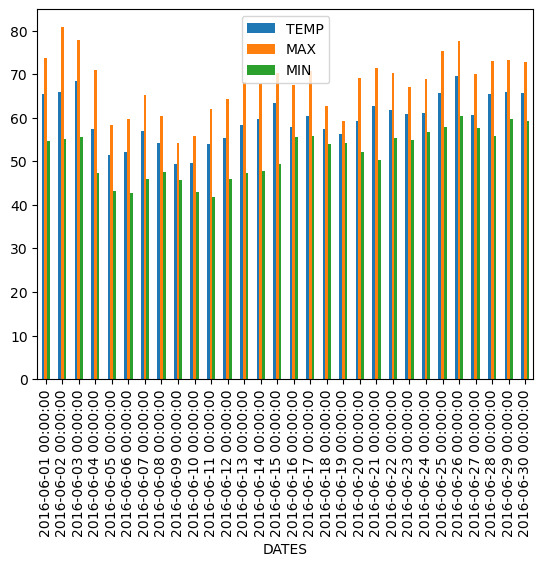

In [62]:
# Plot several columns as bar graphs
dataFrame.plot(x='DATES', y=["TEMP", "MAX", "MIN"],kind="bar",)
plt.show()

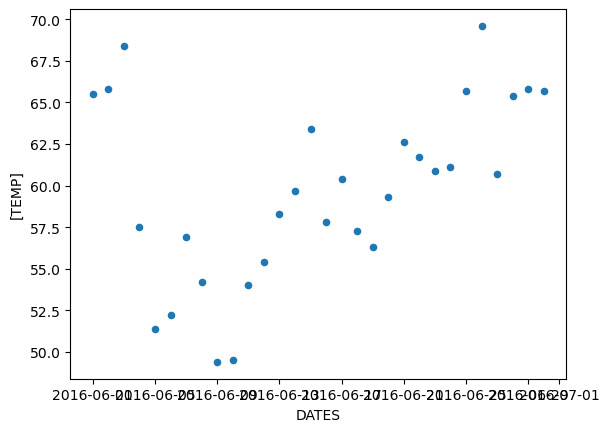

In [63]:
# Scatter plot for one column
dataFrame.plot(x='DATES', y=["TEMP"],kind="scatter",)
plt.show()